# Deutsch's Algorithm

Classify a one-bit Boolean function as constant or balanced using one quantum oracle call. Prepare the auxiliary qubit in |-> so the oracle encodes the function as a phase.

Run the cells from top to bottom in a fresh Python kernel. See the [repository README](../README.md) for environment setup.

**Bit ordering:** Qiskit displays bit strings with the highest-index bit on the left and bit 0 on the right. Ideal simulator results are used here; shot counts can fluctuate when several outcomes have nonzero probability.

## Classifying one oracle

After the final Hadamard, measurement `0` means constant and `1` means balanced. This example uses `balanced01`, meaning f(x) = x. The original call used the unrecognized name `balanced1`; it is corrected here.

Balanced


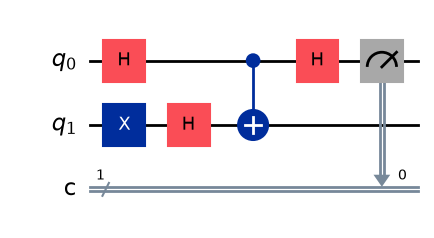

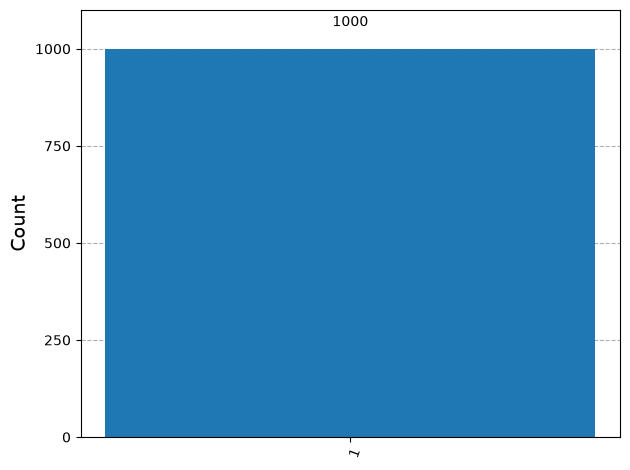

In [1]:
from qiskit import QuantumCircuit, transpile 
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

def oracle(x):
    # Reject unknown names instead of silently using the identity oracle.
    if x not in {"constant0", "constant1", "balanced01", "balanced10"}:
        raise ValueError(f"Unknown oracle type: {x}")
    qc = QuantumCircuit(2)

    if x == "constant1": qc.x(1)
    elif x == "balanced01": qc.cx(0 , 1)
    elif x == "balanced10":
        qc.x(1)
        qc.cx(0, 1)
    return qc

def algo(x):
    qc = QuantumCircuit(2 ,1)
    qc.x(1)
    qc.h([0 , 1])
    qc.compose(oracle(x), inplace=True)
    qc.h(0)
    qc.measure(0 , 0)
    return qc

qc = algo("balanced01")
sm = Aer.get_backend("qasm_simulator")
tc = transpile(qc, sm)

rslt = sm.run(tc, shots = 1000).result()
cnts = rslt.get_counts(qc)

if '0' in cnts and cnts['0'] > cnts.get('1' , 0):
    print("Constant")
else:
    print("Balanced")

display(qc.draw("mpl"))
plot_histogram(cnts)

## Comparing all four Boolean functions

`constant0` and `constant1` always return 0 and 1, respectively; `balanced01` implements x and `balanced10` implements 1 XOR x. Expect measurement `0` for both constant functions and `1` for both balanced functions.

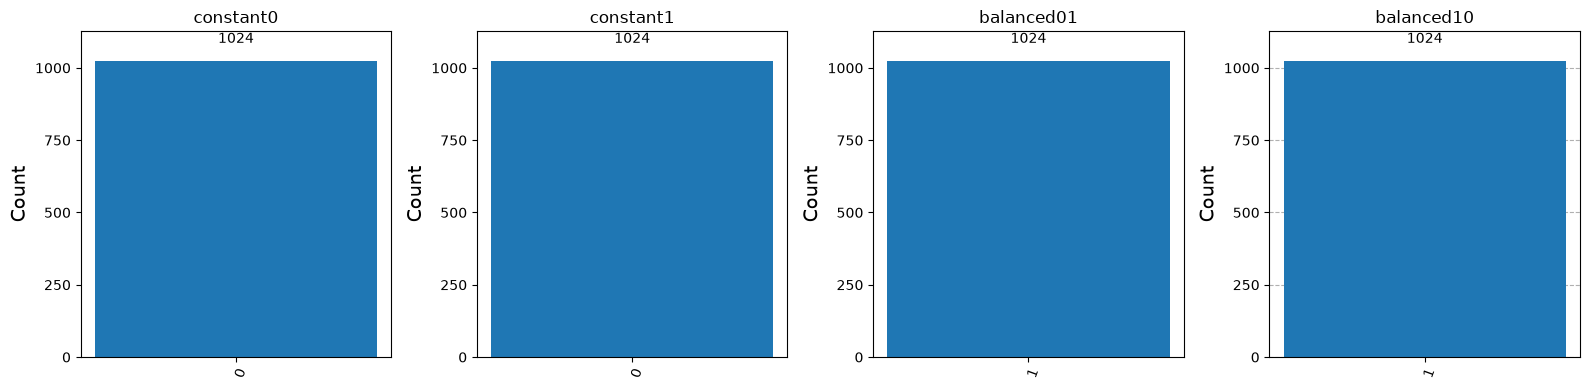

In [2]:
def oracle(x):
    # Reject unknown names instead of silently using the identity oracle.
    if x not in {"constant0", "constant1", "balanced01", "balanced10"}:
        raise ValueError(f"Unknown oracle type: {x}")
    qc = QuantumCircuit(2)
    if x == "constant1": qc.x(1)
    elif x == "balanced01": qc.cx(0 , 1)
    elif x == "balanced10":
        qc.x(1)
        qc.cx(0, 1)
    return qc

def algo(x):
    qc = QuantumCircuit(2 , 1)
    qc.x(1)
    qc.h([0 , 1])
    qc.compose(oracle(x), inplace= True)
    qc.h(0)
    qc.measure(0 , 0)
    return qc

types = ["constant0", "constant1", "balanced01", "balanced10"]
rslts = {}

for x in types:
    qs = algo(x)
    sm = Aer.get_backend("qasm_simulator")
    ts = transpile(qs, sm)
    rslts[x] = sm.run(ts, shots = 1024).result().get_counts(qs)

import matplotlib.pyplot as plt

_ , ax = plt.subplots(1 , 4, figsize = (16 , 4))
for x , y in zip(ax, types):
    plot_histogram(rslts[y], ax = x)
    x.set_title(y)

plt.tight_layout()
plt.show()